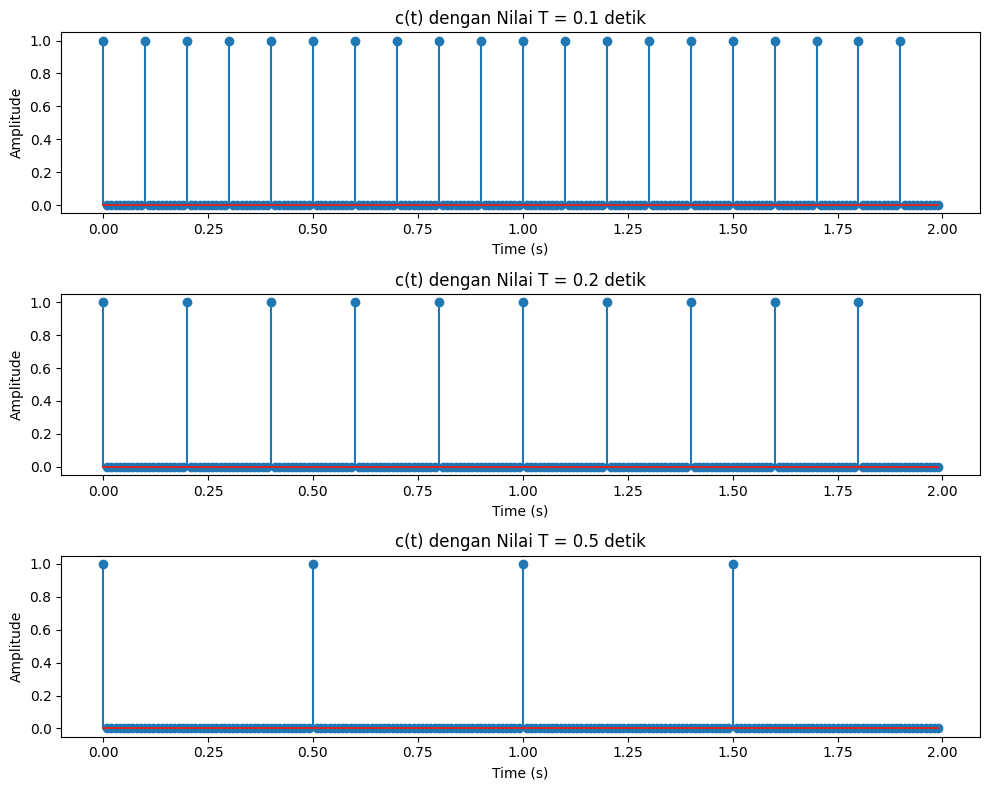

In [36]:
# NAMA : ZIDANE SURYA NUGRAHA
# NIM : 607022400036
# KELAS : D3TK-48-01

# JURNAL 1

import numpy as np
import matplotlib.pyplot as plt

Fs = 100 # Sampling frequency dasar (Hz)
t = np.arange(0, 2, 1/Fs) # Membuat vektor waktu (t) dari 0 hingga 2 detik

# Kita coba 3 nilai T yang berbeda untuk mengamati perubahannya
T_values = [0.1, 0.2, 0.5]

plt.figure(figsize=(10, 8))

for i, T in enumerate(T_values):
    c = np.zeros(len(t))
    # Set setiap elemen ke int menjadi 1
    c[::int(Fs*T)] = 1

    plt.subplot(3, 1, i+1)
    plt.stem(t, c)
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')
    plt.title(f'c(t) dengan Nilai T = {T} detik')

plt.tight_layout()
plt.show()

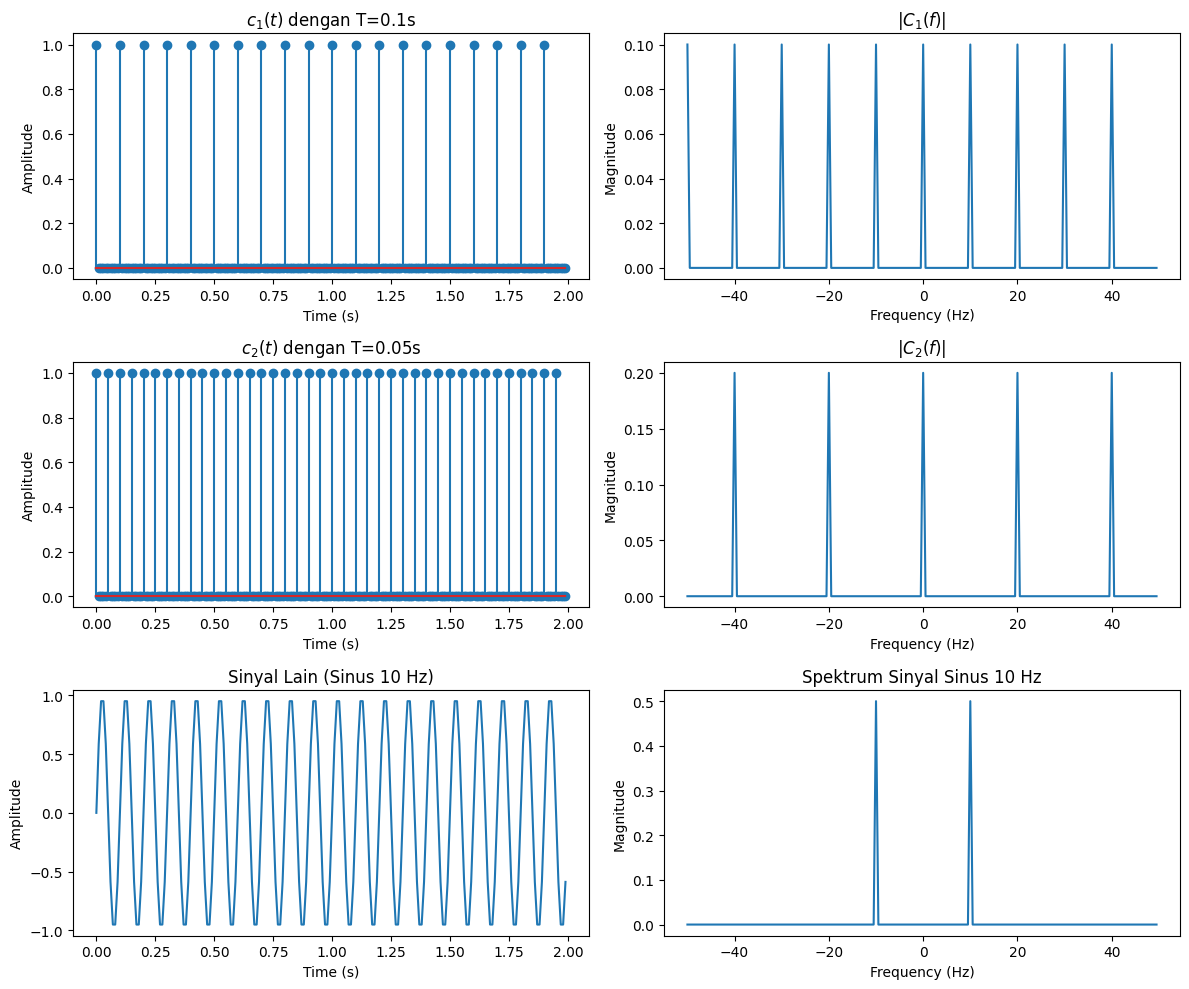

In [37]:
# JURNAL II:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftshift

# Step 1: Generation of comb functions c1(t) dan c2(t)
Fs = 100
t = np.arange(0, 2, 1/Fs)
f = np.linspace(-Fs/2, Fs/2, len(t), endpoint=False)

# Sinyal c1 dengan periode T1 = 0.1 detik
T1 = 0.1
c1 = np.zeros(len(t))
c1[::int(Fs*T1)] = 1

# Sinyal c2 dengan periode T2 = 0.05 detik
T2 = 0.05
c2 = np.zeros(len(t))
c2[::int(Fs*T2)] = 1

# TUGAS TAMBAHAN JURNAL II: Sinyal bentuk lain (Sinyal Sinus 10 Hz)
f_sin = 10
sinyal_lain = np.sin(2 * np.pi * f_sin * t)

# Step 2: Fourier transform dari masing-masing sinyal
C1 = fftshift(fft(c1))
C2 = fftshift(fft(c2))
C_sinyal = fftshift(fft(sinyal_lain))

# Step 3: Plotting the result
plt.figure(figsize=(12, 10))

# Plot c1 (Waktu) dan C1 (Frekuensi)
plt.subplot(3, 2, 1), plt.stem(t, c1), plt.xlabel('Time (s)'), plt.ylabel('Amplitude'), plt.title('$c_1(t)$ dengan T=0.1s')
plt.subplot(3, 2, 2), plt.plot(f, np.abs(C1)/len(C1)), plt.xlabel('Frequency (Hz)'), plt.ylabel('Magnitude'), plt.title('$|C_1(f)|$')

# Plot c2 (Waktu) dan C2 (Frekuensi)
plt.subplot(3, 2, 3), plt.stem(t, c2), plt.xlabel('Time (s)'), plt.ylabel('Amplitude'), plt.title('$c_2(t)$ dengan T=0.05s')
plt.subplot(3, 2, 4), plt.plot(f, np.abs(C2)/len(C2)), plt.xlabel('Frequency (Hz)'), plt.ylabel('Magnitude'), plt.title('$|C_2(f)|$')

# Plot Sinyal Lain (Waktu) dan Transformasinya (Frekuensi)
plt.subplot(3, 2, 5), plt.plot(t, sinyal_lain), plt.xlabel('Time (s)'), plt.ylabel('Amplitude'), plt.title('Sinyal Lain (Sinus 10 Hz)')
plt.subplot(3, 2, 6), plt.plot(f, np.abs(C_sinyal)/len(C_sinyal)), plt.xlabel('Frequency (Hz)'), plt.ylabel('Magnitude'), plt.title('Spektrum Sinyal Sinus 10 Hz')

plt.tight_layout()
plt.show()

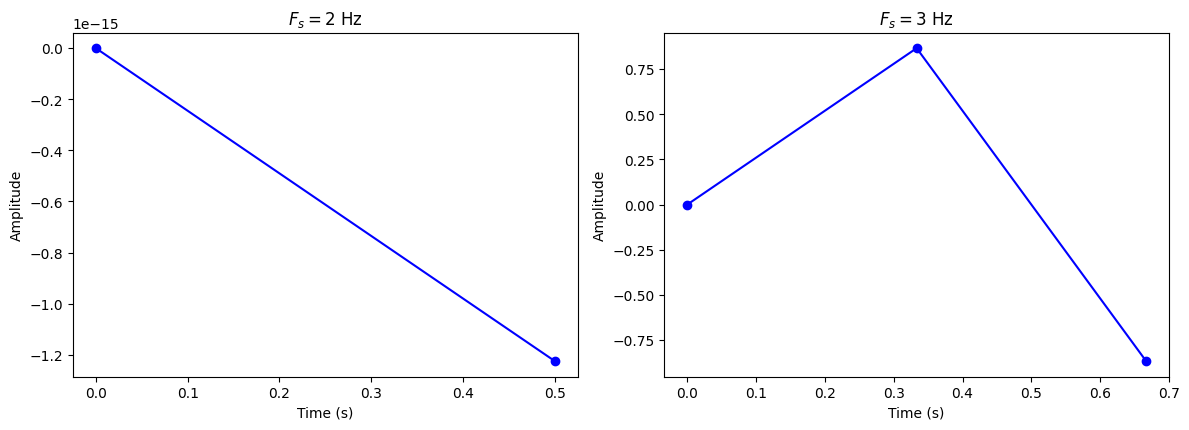

In [38]:
# JURNAL III:
import numpy as np
import matplotlib.pyplot as plt

f = 10  # Frekuensi sinyal analog (10 Hz)
# Kita memvariasikan frekuensi sampling (Fs)
fs = [2, 3]

plt.figure(figsize=(12, 8))

for i in range(len(fs)):
    t = np.arange(0, 1, 1/fs[i])
    x = np.sin(2 * np.pi * f * t)

    plt.subplot(2, 2, i+1)
    # Menambahkan marker 'o' untuk memperjelas titik-titik yang di-sampling
    plt.plot(t, x, marker='o', color='b', linestyle='-')
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')
    plt.title(f'$F_s={fs[i]}$ Hz')

plt.tight_layout()
plt.show()

In [39]:
# JURNAL IV:
import numpy as np
import matplotlib.pyplot as plt
# Menggunakan IPython.display.Audio sebagai pengganti sounddevice untuk Colab
from IPython.display import Audio, display

# Step 1: Parameter sinyal
# Mengubah Fs menjadi 8000 sesuai instruksi Jurnal IV
fs = 8000
dur = 1
t = np.linspace(0, 1, int(dur*fs))

# Step 2: Generate 2 sinyal suara dengan frekuensi berbeda
# Sinyal 1: Frekuensi 500 Hz
x1 = np.sin(2 * np.pi * 500 * t)
# Sinyal 2: Frekuensi 1000 Hz
x2 = np.sin(2 * np.pi * 1000 * t)

# Menggabungkan kedua sinyal agar diputar berurutan
x = np.concatenate([x1, x2])

# Step 3: Memutar suara
print(f"Pemutar Suara dengan Fs = {fs} Hz")
print("Anda akan mendengar dua nada berurutan (500 Hz lalu 1000 Hz)")
display(Audio(x, rate=fs))

Pemutar Suara dengan Fs = 8000 Hz
Anda akan mendengar dua nada berurutan (500 Hz lalu 1000 Hz)


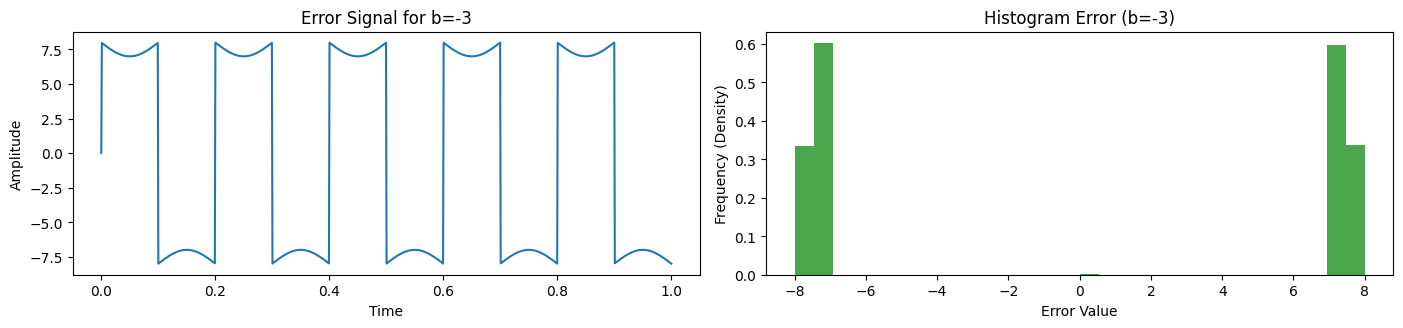

In [40]:
# JURNAL V:
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Generate the input signal
# Jumlah titik diperbanyak menjadi 1000 agar distribusi datanya terlihat lebih jelas di histogram
t = np.linspace(0, 1, 1000)
x = np.sin(2 * np.pi * 5 * t)

# Step 2: Parameters of the quantizer
DR = np.max(x) - np.min(x) # Dynamic range
b = [3-6] # Number of bits

plt.figure(figsize=(14, 12))

for i in range(len(b)):
    L = 2**b[i] # Quantization level
    q = DR / (L) # Quantization step size

    # Step 3: To obtain the quantized signal
    y = np.sign(x) * q * (np.floor((abs(x) / q)) + (1/2))

    # Step 4: Obtain the error signal
    e = y - x

    #TUGAS 1: Plot the error signal
    plt.subplot(4, 2, 2*i + 1)
    plt.plot(t, e)
    plt.xlabel('Time')
    plt.ylabel('Amplitude')
    plt.title(f'Error Signal for b={b[i]}')

    #TUGAS 2: Plot Histogram Error
    plt.subplot(4, 2, 2*i + 2)
    plt.hist(e, bins=30, density=True, color='green', alpha=0.7)
    plt.xlabel('Error Value')
    plt.ylabel('Frequency (Density)')
    plt.title(f'Histogram Error (b={b[i]})')

plt.tight_layout()
plt.show()

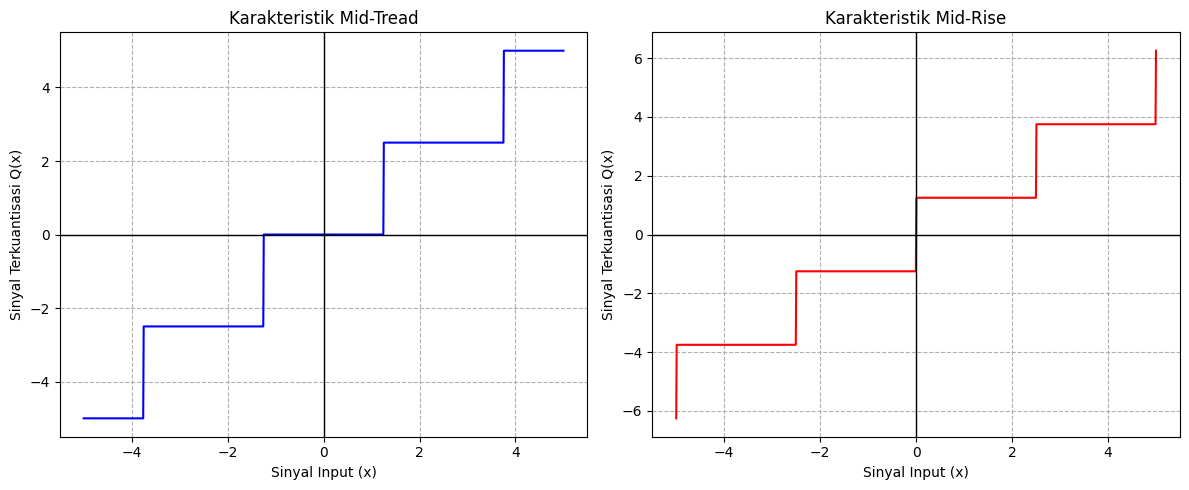

In [41]:
# JURNAL VI:
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Membuat rentang nilai input
x = np.linspace(-5, 5, 1000)
DR = np.max(x) - np.min(x)  # Dynamic range
b = 2
L = 2**b
q = DR / L

# Step 2: Karakteristik Mid-Tread Quantizer
# Perhatikan posisi kurung: floor((abs(x)/q) + 1/2)
y_tread = np.sign(x) * q * np.floor((np.abs(x)/q) + 0.5)

# Step 3: Karakteristik Mid-Rise Quantizer
# Perhatikan posisi kurung: floor(abs(x)/q) + 1/2
y_rise = np.sign(x) * q * (np.floor(np.abs(x)/q) + 0.5)

# Step 4: Plotting perbandingan
plt.figure(figsize=(12, 5))

# Plot Mid-Tread
plt.subplot(1, 2, 1)
plt.plot(x, y_tread, color='blue')
plt.grid(True, which='both', linestyle='--')
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)
plt.xlabel('Sinyal Input (x)')
plt.ylabel('Sinyal Terkuantisasi Q(x)')
plt.title('Karakteristik Mid-Tread')

# Plot Mid-Rise
plt.subplot(1, 2, 2)
plt.plot(x, y_rise, color='red')
plt.grid(True, which='both', linestyle='--')
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)
plt.xlabel('Sinyal Input (x)')
plt.ylabel('Sinyal Terkuantisasi Q(x)')
plt.title('Karakteristik Mid-Rise')

plt.tight_layout()
plt.show()

Memproses Kuantisasi Suara...


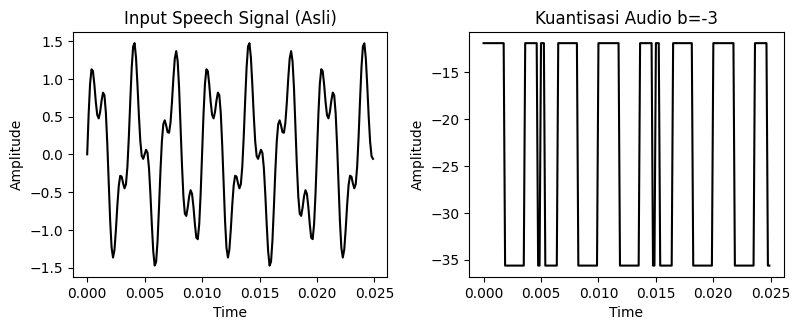


Memproses Kuantisasi Gambar...


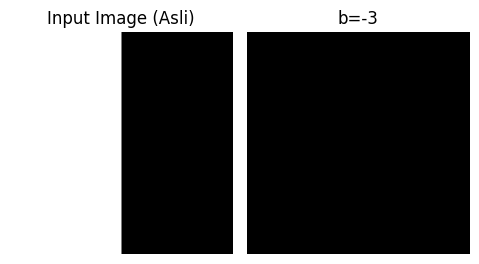

In [42]:
# JURNAL VII
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
import os

# TUGAS 1: KUANTISASI FILE SUARA
print("Memproses Kuantisasi Suara...")

# Menggunakan dummy sinyal suara jika file .wav tidak ada di Colab
samplerate = 8000
duration = 1
t = np.linspace(0, duration, samplerate)
x_audio = np.sin(2 * np.pi * 300 * t) + 0.5 * np.sin(2 * np.pi * 800 * t) # Sinyal suara tiruan

plt.figure(figsize=(12, 6))
plt.subplot(2, 3, 1)
plt.plot(t[:200], x_audio[:200], 'k') # Menampilkan sebagian sinyal (200 sampel)
plt.xlabel('Time'), plt.ylabel('Amplitude')
plt.title('Input Speech Signal (Asli)')

DR_audio = np.max(x_audio) - np.min(x_audio)

b = [3-6]

for i in range(len(b)):
    L = 2**b[i]
    q = DR_audio / L
    y_audio = np.floor(x_audio/q) * q - (q/2)

    plt.subplot(2, 3, i+2)
    plt.plot(t[:200], y_audio[:200], 'k')
    plt.xlabel('Time'), plt.ylabel('Amplitude')
    plt.title(f'Kuantisasi Audio b={b[i]}')

plt.tight_layout()
plt.show()

# TUGAS 2: KUANTISASI GAMBAR (Setengah Putih, Setengah Hitam)
print("\nMemproses Kuantisasi Gambar...")

img = np.zeros((256, 256))
img[:, 0:128] = 255  # Kolom 0 hingga 127 berwarna putih (keabu-abuan 255)
img[:, 128:256] = 0  # Kolom 128 hingga 256 berwarna hitam (keabu-abuan 0)

plt.figure(figsize=(12, 3))
plt.subplot(1, 5, 1)
plt.imshow(img, cmap='gray')
plt.title('Input Image (Asli)')
plt.axis('off')

DR_img = np.max(img) - np.min(img)

for i in range(len(b)):
    L = 2**b[i]
    q = DR_img / L
    # Mid-tread quantization untuk gambar
    y_img = np.sign(img) * q * np.floor((np.abs(img)/q) + 0.5)

    plt.subplot(1, 5, i+2)
    plt.imshow(y_img, cmap='gray')
    plt.title(f'b={b[i]}')
    plt.axis('off')

plt.tight_layout()
plt.show()

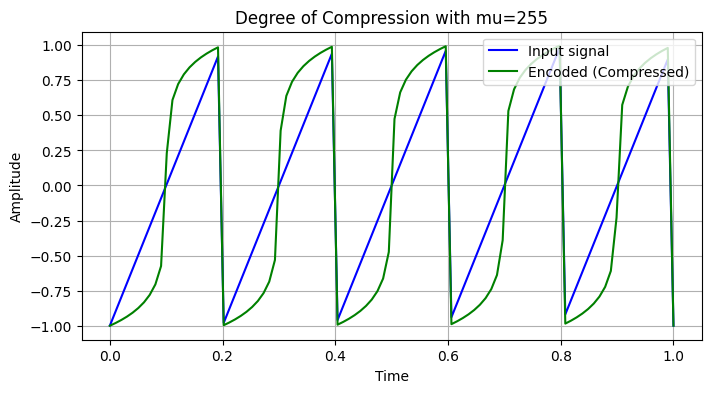

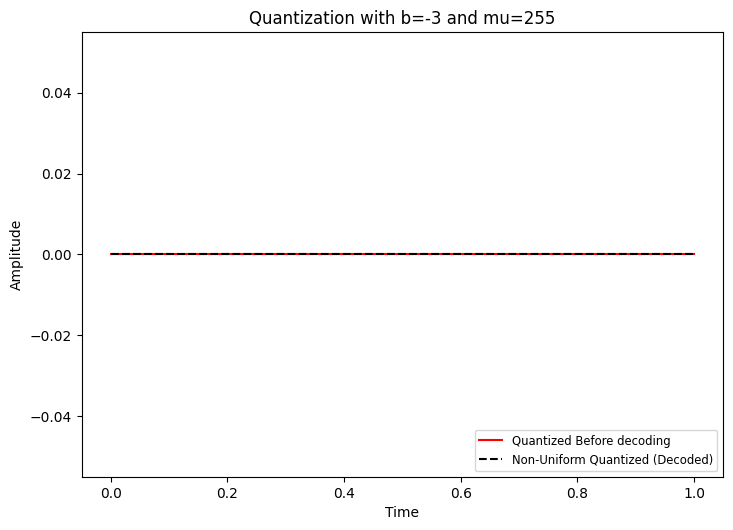

In [43]:
# JURNAL VIII
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# Step 1: Generate the input signal
t1 = np.linspace(0, 1, 100)
x = signal.sawtooth(2 * np.pi * 5 * t1)

# Step 2: Mu law Encoding
mu = 255 # Parameter kompresi Mu-law
y1 = np.sign(x) * ((np.log(1 + (mu * abs(x)))) / np.log(1 + mu))

# Menampilkan grafik kompresi awal
plt.figure(figsize=(8, 4))
plt.plot(t1, x, 'b', label='Input signal')
plt.plot(t1, y1, 'g', label='Encoded (Compressed)')
plt.xlabel('Time'), plt.ylabel('Amplitude')
plt.legend(loc='upper right')
plt.title(f'Degree of Compression with mu={mu}')
plt.grid(True)
plt.show()

# Step 3: Proses Kuantisasi dan Ekspansi (Decoding)
DR = np.max(y1) - np.min(y1) # Dynamic range dari sinyal yang sudah di-encode
b = [3-6] # Number of bits

plt.figure(figsize=(14, 10))
for i in range(len(b)):
    L = 2**b[i] # Quantization level
    q = DR / L  # Quantization step size

    # Kuantisasi sinyal yang sudah dikompresi
    y2 = np.sign(y1) * q * np.floor((abs(y1) / q) + (1/2))

    # Ekspansi mengembalikan sinyal ke skala aslinya
    y = np.sign(y2) * (((1 + mu)**(abs(y2)) - 1) / mu)

    plt.subplot(2, 2, i+1)
    plt.plot(t1, y2, 'r', label='Quantized Before decoding')
    plt.plot(t1, y, 'k', linestyle='--', label='Non-Uniform Quantized (Decoded)')
    plt.xlabel('Time'), plt.ylabel('Amplitude')
    plt.legend(loc='lower right', fontsize='small')
    plt.title(f'Quantization with b={b[i]} and mu={mu}')

plt.tight_layout()
plt.show()